# Ballistic Phonon Transport: Quatrex test



In [1]:
import numpy as np
import phonopy.interface.qe
from numpy.linalg import inv, norm, eigvalsh
import matplotlib.pyplot as plt
import subprocess
import os
import shutil
from pathlib import Path
from scipy.io import savemat

# Physical constants
AMU_KG = 1.66053906660e-27
EV_PER_A2_TO_SI = 1.602176634e-19 / (1e-10) ** 2  # eV/A^2 -> kg/s^2
HBAR_EV = 6.582119569e-16  # eV*s
KB_EV = 8.617333262e-5  # eV/K
THZ_TO_RAD = 2 * np.pi * 1e12  # THz -> rad/s
EV_TO_J = 1.602176634e-19
M_SI_KG = 28.085 * AMU_KG

# Working directory
work_dir = Path(".").resolve()
print(f"Working directory: {work_dir}")

Working directory: /home/paul/Documents/ETH/master/quatrex/phonon/input_calc


## Crystal Structure

Si diamond cubic conventional unit cell: 8 atoms, transport along z.

In [2]:
# a_Si = 5.431  # Angstrom
a_Si = 5.4018 # (paper)

frac_positions = np.array([
    [0.00, 0.00, 0.00],
    [0.50, 0.50, 0.00],
    [0.50, 0.00, 0.50],
    [0.00, 0.50, 0.50],
    [0.25, 0.25, 0.25],
    [0.75, 0.75, 0.25],
    [0.75, 0.25, 0.75],
    [0.25, 0.75, 0.75],
])

lattice_vectors = np.diag([a_Si, a_Si, a_Si])
positions_cart = frac_positions * a_Si
n_atoms = 8
n_dof = 3 * n_atoms

## QE relaxation


In [3]:
def write_qe_input(filename, frac_pos, cell, symbols, ecutwfc=36,
                    kpts=(4, 4, 4), calculation='scf', pseudo_dir='./pseudo'):
    """Write a Quantum ESPRESSO pw.x input file."""
    pseudos = {'Si': 'Si.pbe-n-rrkjus_psl.1.0.0.UPF'}
    masses = {'Si': 28.085}
    unique = list(dict.fromkeys(symbols))

    with open(filename, 'w') as f:
        f.write("&CONTROL\n")
        f.write(f"   calculation      = '{calculation}'\n")
        f.write("   restart_mode     = 'from_scratch'\n")
        f.write("   prefix           = 'phonon_fc'\n")
        f.write(f"   pseudo_dir       = '{pseudo_dir}'\n")
        f.write("   outdir           = './results'\n")
        f.write("   tprnfor          = .true.\n")
        f.write("/\n")
        f.write("&SYSTEM\n")
        f.write("   ibrav            = 0\n")
        f.write(f"   nat              = {len(symbols)}\n")
        f.write(f"   ntyp             = {len(unique)}\n")
        f.write(f"   ecutwfc          = {ecutwfc}\n")
        f.write(f"   ecutrho          = {ecutwfc * 8}\n")
        f.write("   occupations      = 'smearing'\n")
        f.write("   smearing         = 'gaussian'\n")
        f.write("   degauss          = 0.01\n")
        f.write("/\n")
        f.write("&ELECTRONS\n")
        f.write("   conv_thr         = 1e-10\n")
        f.write("/\n")
        if calculation == 'relax':
            f.write("&IONS\n")
            f.write("   ion_dynamics     = 'bfgs'\n")
            f.write("/\n")
            f.write("&CELL\n")
            f.write("/\n")
        f.write("ATOMIC_SPECIES\n")
        for sp in unique:
            f.write(f"  {sp}  {masses[sp]}  {pseudos[sp]}\n")
        f.write("ATOMIC_POSITIONS crystal\n")
        for sym, pos in zip(symbols, frac_pos):
            f.write(f"  {sym}  {pos[0]:.10f}  {pos[1]:.10f}  {pos[2]:.10f}\n")
        f.write("CELL_PARAMETERS angstrom\n")
        for v in cell:
            f.write(f"  {v[0]:.10f}  {v[1]:.10f}  {v[2]:.10f}\n")
        f.write(f"K_POINTS automatic\n")
        f.write(f"  {kpts[0]} {kpts[1]} {kpts[2]}  0 0 0\n")


def read_qe_forces(filename, natoms):
    """Parse forces from QE pw.x output. Returns (natoms, 3) in eV/Ang."""
    RY_BOHR_TO_EV_ANG = 25.71104309541616
    with open(filename) as f:
        text = f.read()
    if 'JOB DONE' not in text:
        raise RuntimeError(f"QE did not converge: {filename}")
    forces = []
    for line in text.split('Forces acting on atoms')[-1].split('\n'):
        if 'force =' in line:
            vals = line.split('force =')[1].split()
            forces.append([float(v) for v in vals[:3]])
        if len(forces) == natoms:
            break
    if len(forces) != natoms:
        raise ValueError(f"Expected {natoms} forces, got {len(forces)}")
    return np.array(forces) * RY_BOHR_TO_EV_ANG

In [5]:
# Relaxation
relax_dir = work_dir / 'relax'
relax_out = relax_dir / 'relax.out'

relax_dir.mkdir(exist_ok=True)
(relax_dir / 'results').mkdir(exist_ok=True)
if not (relax_dir / 'pseudo').exists():
    os.symlink(work_dir / 'pseudo', relax_dir / 'pseudo')

write_qe_input(
    relax_dir / 'relax.in', frac_positions, lattice_vectors,
    ['Si'] * 8, ecutwfc=60, kpts=(8, 8, 8), calculation='relax',
)
print("Running QE relaxation")
result = subprocess.run(
    'pw.x < relax.in > relax.out 2>&1',
    shell=True, cwd=relax_dir,
)
print(f"  exit code: {result.returncode}")


Running QE relaxation


KeyboardInterrupt: 

## Force Constants from Phonopy


In [4]:
from phonopy import Phonopy
from phonopy.structure.atoms import PhonopyAtoms

ph_cell = PhonopyAtoms(
    symbols=['Si'] * 8,
    cell=lattice_vectors,
    scaled_positions=frac_positions,
)
phonon = Phonopy(
    ph_cell,
    supercell_matrix=np.diag([2, 2, 2]),
    primitive_matrix=np.eye(3),
)
phonon.generate_displacements(distance=0.01)

n_disp = len(phonon.displacements)
n_super = len(phonon.supercell.positions)
print(f"Supercell: {n_super} atoms")
print(f"Displacements: {n_disp}")

Supercell: 64 atoms
Displacements: 1


In [7]:
scf_dir = work_dir / 'scf_disp'
scf_dir.mkdir(exist_ok=True)
(scf_dir / 'results').mkdir(exist_ok=True)
if not (scf_dir / 'pseudo').exists():
    os.symlink(work_dir / 'pseudo', scf_dir / 'pseudo')

force_sets = []
all_done = True

for i, sc in enumerate(phonon.supercells_with_displacements):
    tag = f'disp-{i+1:03d}'
    in_file = scf_dir / f'{tag}.in'
    out_file = scf_dir / f'{tag}.out'

    # Write input
    write_qe_input(
        in_file, sc.scaled_positions, sc.cell,
        ['Si'] * n_super, ecutwfc=36, kpts=(2, 2, 2),
        pseudo_dir='./pseudo',
    )

    # Run if output doesn't exist
    if not out_file.exists():
        print(f"  Running {tag}...", flush=True)
        subprocess.run(
            f'pw.x < {tag}.in > {tag}.out 2>&1',
            shell=True, cwd=scf_dir,
        )

    # Parse forces
    try:
        forces = read_qe_forces(out_file, n_super)
        force_sets.append(forces)
        print(f"  {tag}: max |F| = {np.max(np.abs(forces)):.6f} eV/A")
    except Exception as e:
        print(f"  {tag}: FAILED -- {e}")
        all_done = False

if not all_done:
    raise RuntimeError("Not all SCF calculations completed successfully.")
print(f"\nAll {n_disp} displacements done.")

  disp-001: max |F| = 0.134330 eV/A

All 1 displacements done.


In [8]:
import phonopy.interface.qe

In [14]:
phonon.forces = phonopy.interface.qe.parse_set_of_forces(64, ['scf_disp/supercell-001.out'])

1. Drift force of "scf_disp/supercell-001.out" to be subtracted
 -0.00000000   0.00000000   0.00000000


In [15]:
# Compute force constants


#phonon.forces = np.array(force_sets)
phonon.produce_force_constants()

fc = phonon.force_constants
print(f"Force constants shape: {fc.shape}") # fc[prim_atom, super_atom, 3, 3]

Force constants shape: (64, 64, 3, 3)


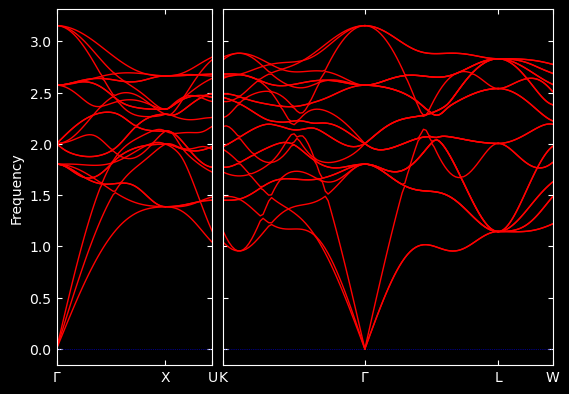

In [21]:
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections

path = [[[0, 0, 0], [0.5, 0, 0.5], [0.625, 0.25, 0.625]],
        [[0.375, 0.375, 0.75], [0, 0, 0], [0.5, 0.5, 0.5], [0.5, 0.25, 0.75]]]
labels = ["$\\Gamma$", "X", "U", "K", "$\\Gamma$", "L", "W"]
qpoints, connections = get_band_qpoints_and_path_connections(path, npoints=51)

phonon.run_band_structure(qpoints, path_connections=connections, labels=labels)
phonon.plot_band_structure().show()

## Extract Dynamical Matrix Blocks

Use phonopy's dynamical matrix D(q) on a 3x3x3 q-mesh, then inverse DFT
to get real-space blocks D(nz, nx, ny) in (rad/s)^2 units.


In [ ]:
CONVERSION = EV_PER_A2_TO_SI / AMU_KG  # phonopy eigenvalue -> (rad/s)^2

# Evaluate D(q) on Nq^3 mesh using phonopy API
Nq = 3
D_q = np.zeros((Nq, Nq, Nq, n_dof, n_dof), dtype=complex)
for i in range(Nq):
    for j in range(Nq):
        for k in range(Nq):
            D_q[i, j, k] = phonon.get_dynamical_matrix_at_q([i / Nq, j / Nq, k / Nq])

# Inverse DFT: D(R) = (1/N^3) sum_q D(q) exp(-2pi i q.R)
# D(R) is complex for multi-atom cells (basis-atom phase factors)
D_blocks = {}
for nx in range(-1, 2):
    for ny in range(-1, 2):
        for nz in range(-1, 2):
            D_R = np.zeros((n_dof, n_dof), dtype=complex)
            for i in range(Nq):
                for j in range(Nq):
                    for k in range(Nq):
                        phase = np.exp(-2j * np.pi * (nx * i + ny * j + nz * k) / Nq)
                        D_R += D_q[i, j, k] * phase
            D_R /= Nq**3
            D_R *= CONVERSION
            if np.max(np.abs(D_R)) > 1e10:
                D_blocks[(nz, nx, ny)] = D_R

print(f"Extracted {len(D_blocks)} real-space DM blocks")
for key in sorted(D_blocks):
    print(f"  {key}: max |D| = {np.max(np.abs(D_blocks[key])):.3e}")

In [ ]:
# Gamma validation: sum all blocks -> should give 3 acoustic modes at 0
D_gamma = sum(D_blocks.values())
eigs = eigvalsh(D_gamma)
freqs_gamma = np.sign(eigs) * np.sqrt(np.abs(eigs)) / THZ_TO_RAD

print("Gamma-point frequencies (THz):")
print(f"  {np.sort(freqs_gamma).round(4)}")
print(f"  3 acoustic (should be ~0): {np.sort(np.abs(freqs_gamma))[:3].round(6)}")
print(f"  Hermiticity: max|D-D^H| = {np.max(np.abs(D_gamma - D_gamma.conj().T)):.2e}")

# Check D(R)^H = D(-R) (time-reversal symmetry)
def split_fc_by_z(blocks):
    K_00, K_01, K_m1 = {}, {}, {}
    for (nz, nx, ny), D in blocks.items():
        if nz == 0:   K_00[(nx, ny)] = D
        elif nz == 1: K_01[(nx, ny)] = D
        elif nz == -1: K_m1[(nx, ny)] = D
    return K_00, K_01, K_m1

K_00, K_01, K_m1 = split_fc_by_z(D_blocks)
max_err = 0
for (nx, ny), D01 in K_01.items():
    Dm1 = K_m1.get((-nx, -ny))
    if Dm1 is not None:
        max_err = max(max_err, np.max(np.abs(D01.conj().T - Dm1)))
print(f"  max|D_01(R)^H - D_m1(-R)| = {max_err:.2e}")

# Band structure comparison: phonopy direct vs reconstructed from blocks
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections

path = [[[0, 0, 0], [0.5, 0, 0.5], [0.625, 0.25, 0.625]],
        [[0.375, 0.375, 0.75], [0, 0, 0], [0.5, 0.5, 0.5], [0.5, 0.25, 0.75]]]
labels = ["$\\Gamma$", "X", "U", "K", "$\\Gamma$", "L", "W"]
qpoints, connections = get_band_qpoints_and_path_connections(path, npoints=51)

freqs_phonopy_band = []
freqs_blocks_band = []
for seg_qpts in qpoints:
    for q in seg_qpts:
        # Phonopy direct
        D_ph = phonon.get_dynamical_matrix_at_q(q) * CONVERSION
        e_ph = eigvalsh(D_ph)
        freqs_phonopy_band.append(np.sign(e_ph) * np.sqrt(np.abs(e_ph)) / THZ_TO_RAD)

        # Reconstructed from extracted blocks
        D_rec = sum(
            D_R * np.exp(2j * np.pi * (nx * q[0] + ny * q[1] + nz * q[2]))
            for (nz, nx, ny), D_R in D_blocks.items()
        )
        e_bl = eigvalsh(D_rec)
        freqs_blocks_band.append(np.sign(e_bl) * np.sqrt(np.abs(e_bl)) / THZ_TO_RAD)

freqs_phonopy_band = np.array(freqs_phonopy_band)
freqs_blocks_band = np.array(freqs_blocks_band)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(freqs_phonopy_band))
for b in range(freqs_phonopy_band.shape[1]):
    ax.plot(x, freqs_phonopy_band[:, b], "b-", lw=1, alpha=0.6,
            label="phonopy" if b == 0 else None)
    ax.plot(x, freqs_blocks_band[:, b], "r--", lw=0.8, alpha=0.6,
            label="extracted blocks" if b == 0 else None)

cum = 0
ticks = [0]
for seg_qpts in qpoints:
    cum += len(seg_qpts)
    ticks.append(cum - 1)
ax.set_xticks(ticks[:len(labels)])
ax.set_xticklabels(labels)
for t in ticks:
    ax.axvline(x=t, color="gray", lw=0.5)

ax.set_ylabel("Frequency (THz)")
ax.set_title("Band structure: phonopy vs extracted blocks")
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(freqs_phonopy_band - freqs_blocks_band))
print(f"Max band structure difference: {max_diff:.6f} THz")

## quatrex Inputs

- `dynamical_matrix.mat` -- mass-normalized DM blocks in (rad/s)^2 units
- `structure.xyz` -- extended XYZ with lattice vectors
- `quatrex_config.toml` -- simulation parameters


In [ ]:
quatrex_dir = work_dir / "quatrex_inputs"
quatrex_dir.mkdir(exist_ok=True)

num_transport_cells = 4
nq = 4  # transverse q-mesh (4x4)

# --- dynamical_matrix.mat ---
mat_dict = {}
for (nz, nx, ny), D in D_blocks.items():
    mat_dict[f"[{nx}, {ny}, {nz}]"] = D
savemat(str(quatrex_dir / "dynamical_matrix.mat"), mat_dict)
print(f"Saved dynamical_matrix.mat ({len(mat_dict)} blocks, (rad/s)^2 units)")

# --- structure.xyz ---
with open(quatrex_dir / "structure.xyz", "w") as f:
    f.write(f"{n_atoms}\n")
    lv = lattice_vectors
    f.write(
        f'Lattice="{lv[0,0]} {lv[0,1]} {lv[0,2]} '
        f'{lv[1,0]} {lv[1,1]} {lv[1,2]} '
        f'{lv[2,0]} {lv[2,1]} {lv[2,2]}" '
        f'Properties=species:S:1:pos:R:3 pbc="T T T"\n'
    )
    for pos in positions_cart:
        f.write(f"Si  {pos[0]:.8f}  {pos[1]:.8f}  {pos[2]:.8f}\n")
print(f"Saved structure.xyz ({n_atoms} atoms)")

# --- quatrex_config.toml ---
config_text = f"""simulation_dir = "."
input_dir = "."

formalism = "negf"
simulation_type = "phonon"

[device]
transport_direction = 'z'
construct_from_unit_cell = true
num_transport_cells = {num_transport_cells}
neighbor_cell_cutoff = [1, 1, 1]
kpoint_grid = [{nq}, {nq}, 1]
kpoint_shift = [0.0, 0.0, 0.0]

[device.num_orbitals_per_atom]
Si = 3

[scba]
max_iterations = 1
phonon = true

[electron]
energy_window_min = -1.0
energy_window_max = 1.0
energy_window_num = 10
fermi_level = 0.0
conduction_band_edge = 0.5
valence_band_edge = -0.5
left_fermi_level = 0.0
right_fermi_level = 0.0

[phonon]
eta = 1e-8
eta_obc = 0.0
left_temperature = 301.0
right_temperature = 299.0
model = "negf"
phonon_energy = 0.063
deformation_potential = 1.0

[phonon.solver]
compute_current = true

[phonon.obc]
algorithm = "sancho-rubio"
block_sections = 1
"""
with open(quatrex_dir / "quatrex_config.toml", "w") as f:
    f.write(config_text)
print(f"Saved quatrex_config.toml")
print(f"  transport cells: {num_transport_cells}, q-mesh: {nq}x{nq}")

## Run ballistic PhononSolver


In [ ]:
import sys
import warnings

sys.path.insert(0, str(Path(work_dir).parents[1] / "src"))
warnings.filterwarnings("ignore")

from qttools import xp, sparse
from qttools.comm import comm
from qttools.utils.mpi_utils import get_local_slice
from quatrex.core.config import parse_config
from quatrex.core.statistics import bose_einstein
from quatrex.phonon.solver import PhononSolver
from quatrex.device.inputs import load_matrix

In [ ]:
os.chdir(quatrex_dir)

# Frequency grid
n_freq = 201
freqs_thz = np.linspace(0.01, 16.0, n_freq)
omega_rad = freqs_thz * THZ_TO_RAD
omega_sq = omega_rad**2

# Config
config = parse_config("quatrex_config.toml")
config.phonon.eta = 1e20  # (rad/s)^2 broadening

# Load dynamical matrix to get sparsity pattern
dm_temp, sp = load_matrix(
    config=config, matrix_name="dynamical_matrix",
    sparsity_pattern=None, shift_kpoints=False,
)
sparsity_pattern = sp.copy()
del dm_temp

# Create solver
solver = PhononSolver(config, omega_sq, sparsity_pattern)

local_freqs = get_local_slice(omega_sq, comm.stack)
local_omega_rad = np.sqrt(np.abs(local_freqs))
hbar_omega_eV = HBAR_EV * local_omega_rad
T_L, T_R = 301.0, 299.0
solver.left_occupancies = bose_einstein(hbar_omega_eV, T_L)
solver.right_occupancies = bose_einstein(hbar_omega_eV, T_R)
solver.left_temperature = T_L
solver.right_temperature = T_R

print(f"Solver ready: {n_freq} freqs, {nq}x{nq} q-mesh")
print(f"  block sizes: {solver.block_sizes}")
print(f"  eta = {config.phonon.eta:.0e}")

In [ ]:
# Allocate Green's functions and zero self-energies (ballistic)
DSDB = type(solver.dynamical_matrix)
stack_shape = omega_sq.shape + tuple(
    [int(k) for k in config.device.kpoint_grid if k > 1]
)

g_lesser = DSDB.from_sparray(
    sp.astype(xp.complex128),
    block_sizes=solver.block_sizes,
    global_stack_shape=stack_shape,
)
g_greater = DSDB.zeros_like(g_lesser)
g_retarded = DSDB.zeros_like(g_lesser)
sse_lesser = DSDB.zeros_like(g_lesser)
sse_greater = DSDB.zeros_like(g_lesser)
sse_retarded = DSDB.zeros_like(g_lesser)

out = (g_lesser, g_greater, g_retarded)

print("Solving...")
solver.solve(sse_lesser, sse_greater, sse_retarded, out)
print("Done.")

In [ ]:
# Extract transmission from Meir-Wingreen current
current = solver.meir_wingreen_current  # (n_freq, kx, ky, n_blocks-1)
dn = solver.left_occupancies - solver.right_occupancies
n_kpoints = nq * nq

# Sum spectral current over k-points (first block interface)
spectral_current = current[:, :, :, 0].real
total_current = np.sum(spectral_current, axis=(1, 2))

# T(omega) = I(omega) / (n_L - n_R) / N_k
mask = np.abs(dn) > 1e-20
trans_quatrex = np.zeros(n_freq)
trans_quatrex[mask] = total_current[mask] / dn[mask] / n_kpoints

# Current conservation check
n_interfaces = current.shape[-1]
for i in range(n_interfaces):
    ci = np.sum(current[:, :, :, i].real, axis=(1, 2))
    print(f"Interface {i}: max |I| = {np.max(np.abs(ci)):.4e}")

print(f"\nMax transmission: {trans_quatrex.max():.4f}")

## Reference (Sancho-Rubio + Caroli)


In [ ]:
def sancho_rubio(omega_sq, phi_00, phi_01, eta=1e-4, max_iter=300, tol=1e-8):
    "Surface Green's function via Sancho-Rubio decimation."
    N = phi_00.shape[0]
    phi_10 = phi_01.conj().T

    a_ii = (omega_sq + 1j * eta) * np.eye(N) - phi_00
    a_ij = -phi_01
    a_ji = -phi_10

    eps = a_ii.copy()
    eps_s = a_ii.copy()
    alpha = a_ji.copy()
    beta = a_ij.copy()

    for _ in range(max_iter):
        inv_eps = inv(eps)
        eps_s -= alpha @ inv_eps @ beta
        eps -= alpha @ inv_eps @ beta + beta @ inv_eps @ alpha
        alpha_new = alpha @ inv_eps @ alpha
        beta_new = beta @ inv_eps @ beta
        alpha, beta = alpha_new, beta_new
        if norm(alpha) + norm(beta) < tol:
            break

    return inv(eps_s)


def ballistic_transmission(omega_sq, phi_D, phi_L00, phi_L01,
                           phi_R00, phi_R01, phi_LD, phi_DR, eta=1e-4):
    "Ballistic transmission via Caroli: T = Tr(Gamma_L G^R Gamma_R G^A)."
    N_D = phi_D.shape[0]

    g_L = sancho_rubio(omega_sq, phi_L00, phi_L01, eta)
    g_R = sancho_rubio(omega_sq, phi_R00, phi_R01.conj().T, eta)

    Sigma_L = phi_LD.conj().T @ g_L @ phi_LD
    Sigma_R = phi_DR @ g_R @ phi_DR.conj().T

    Gamma_L = 1j * (Sigma_L - Sigma_L.conj().T)
    Gamma_R = 1j * (Sigma_R - Sigma_R.conj().T)

    G_R = inv((omega_sq + 1j * eta) * np.eye(N_D) - phi_D - Sigma_L - Sigma_R)
    G_A = G_R.conj().T

    T = np.real(np.trace(Gamma_L @ G_R @ Gamma_R @ G_A))
    return max(T, 0.0)


def thermal_conductance(freqs_thz, transmission, T_kelvin, a_lat):
    "Ballistic thermal conductance per unit area [W/(m^2 K)]."
    omegas = freqs_thz * THZ_TO_RAD
    hw = HBAR_EV * omegas
    x = hw / (KB_EV * T_kelvin)

    dfdt = np.zeros_like(x)
    valid = (x > 1e-10) & (x < 500)
    dfdt[valid] = (hw[valid] / (KB_EV * T_kelvin**2)) * (
        np.exp(x[valid]) / (np.exp(x[valid]) - 1) ** 2
    )

    dw = (freqs_thz[1] - freqs_thz[0]) * THZ_TO_RAD
    integrand = transmission * hw * dfdt * dw / (2 * np.pi)
    A_c = (a_lat * 1e-10) ** 2
    return np.sum(integrand) * EV_TO_J / A_c


def get_btd_from_phonopy(phonon, q_perp_frac):
    "Get D_00, D_01 in (rad/s)^2 at transverse q-point using phonopy."
    nd = len(phonon.primitive.masses) * 3
    Nqz = 3
    D_qz = np.zeros((Nqz, nd, nd), dtype=complex)
    for k in range(Nqz):
        D_qz[k] = phonon.get_dynamical_matrix_at_q([q_perp_frac[0], q_perp_frac[1], k / Nqz])
    phases = np.exp(-2j * np.pi * np.arange(Nqz) / Nqz)
    D_00 = np.mean(D_qz, axis=0) * CONVERSION
    D_01 = np.einsum("k,kij->ij", phases, D_qz) / Nqz * CONVERSION
    return D_00, D_01

print("Defined: sancho_rubio, ballistic_transmission, thermal_conductance, get_btd_from_phonopy")

In [ ]:
# Compute reference ballistic transmission using phonopy D(q)
q_frac_1d = [(2 * n - nq - 1) / (2 * nq) for n in range(1, nq + 1)]
q_points_frac = [(qx, qy) for qx in q_frac_1d for qy in q_frac_1d]

freqs_ref = np.linspace(0.01, 16.0, n_freq)
omega_sqs_ref = (freqs_ref * THZ_TO_RAD) ** 2
dw_ref = (freqs_ref[1] - freqs_ref[0]) * THZ_TO_RAD
eta_ref = dw_ref**2 * 0.5

T_kelvin = 300.0

trans_ref = np.zeros(n_freq)
print(f"Reference: {n_freq} freqs x {len(q_points_frac)} q-points")

for iq, (qxf, qyf) in enumerate(q_points_frac):
    D_00_ref, D_01_ref = get_btd_from_phonopy(phonon, [qxf, qyf])
    for iw, w2 in enumerate(omega_sqs_ref):
        trans_ref[iw] += ballistic_transmission(
            w2, D_00_ref, D_00_ref, D_01_ref,
            D_00_ref, D_01_ref, D_01_ref, D_01_ref, eta=eta_ref,
        )

trans_ref /= len(q_points_frac)
print(f"Max reference transmission: {trans_ref.max():.4f}")

## Comparison


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(freqs_ref, trans_ref, "b-", lw=1.5, label="Reference (Caroli)")
ax.plot(freqs_thz, trans_quatrex, "r--", lw=1.5, label="quatrex PhononSolver")
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Transmission")
ax.set_title("Ballistic phonon transmission: pure Si")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

print(f"Max transmission: ref={trans_ref.max():.4f}, quatrex={trans_quatrex.max():.4f}")

In [ ]:
G_ref = thermal_conductance(freqs_ref, trans_ref, T_kelvin, a_Si)
G_quatrex = thermal_conductance(freqs_thz, trans_quatrex, T_kelvin, a_Si)

print(f"Thermal conductance @ {T_kelvin} K")
print(f"  Reference:            {G_ref:.1f} MW/(m^2 K)")
print(f"  quatrex PhononSolver: {G_quatrex:.1f} MW/(m^2 K)")
rel = abs(G_ref - G_quatrex) / G_ref * 100
print(f"  Relative difference:  {rel:.1f}%")

# Save
os.chdir(work_dir)

save_data = {}
for (nz, nx, ny), D in D_blocks.items():
    save_data[f"D_{nz}_{nx}_{ny}"] = D
save_data["a"] = a_Si
save_data["conversion"] = CONVERSION

np.savez("si_force_constants.npz", **save_data)
print(f"\nSaved si_force_constants.npz")